# Notebook 06: Temperature Scaling and Internal-Test Evaluation — Proposed EfficientNetV2-S

This notebook:

1. Loads the selected EfficientNetV2-S checkpoint from Notebook 05 (epoch 13,
   calibration macro-F1 = 0.997892).
2. Fits a single temperature parameter on the Main19 calibration set
   (3,197 images) — the same set used for model selection, not the test set.
3. Evaluates uncalibrated and temperature-scaled predictions on the locked
   internal-test manifest (5,322 images) — its first and only use for this model.
4. Compares the proposed model against the EfficientNet-B0 baseline
   (Notebook 04) under identical metrics.

No hyperparameter, architecture, or threshold decision is made after viewing
these test results.

In [1]:
import os
import json
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 7

os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

if DEVICE.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    capability = torch.cuda.get_device_capability(0)
    print("GPU:", gpu_name)
    print("CUDA capability:", capability)

    assert capability >= (7, 0), (
        f"{gpu_name} has capability {capability}. Select a T4 or newer GPU."
    )
else:
    raise RuntimeError("GPU not detected. Enable a Kaggle T4 GPU.")

Device: cuda
PyTorch: 2.10.0+cu128
GPU: Tesla T4
CUDA capability: (7, 5)


In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,

    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.edgecolor": "0.4",

    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})


def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.7)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(which="both", direction="in", top=True, right=True)


np.random.seed(SEED)
print("Paper plotting style enabled.")

Paper plotting style enabled.


In [3]:
INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

OUTPUT_DIR = WORK_DIR / "proposed_model_test_evaluation_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, METADATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/proposed_model_test_evaluation_outputs


In [4]:
def find_input_file(file_name):
    matches = list(INPUT_ROOT.rglob(file_name))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find '{file_name}' under /kaggle/input.\n"
            "Attach Notebook-02 splits, Notebook-03 baseline outputs, "
            "and Notebook-05 proposed-model outputs."
        )

    if len(matches) > 1:
        print(f"Multiple matches for {file_name}:")
        for match in matches:
            print(" -", match)
        print("Using:", matches[0])

    return matches[0]


TRAIN_MANIFEST_PATH = find_input_file("main19_train.csv")
CALIBRATION_MANIFEST_PATH = find_input_file("main19_calibration.csv")
TEST_MANIFEST_PATH = find_input_file("main19_internal_test.csv")
CLASS_MAPPING_PATH = find_input_file("class_to_index_main19.json")
PROTOCOL_PATH = find_input_file("data_protocol.json")

PROPOSED_CHECKPOINT_PATH = find_input_file(
    "best_efficientnetv2s_main19.pt"
)
PROPOSED_CONFIG_PATH = find_input_file("training_config.json")

# Baseline (Notebook 04) results for the final comparison table.
try:
    BASELINE_METRICS_PATH = find_input_file(
        "main19_temperature_scaling_metrics.csv"
    )
    baseline_available = True
except FileNotFoundError:
    print(
        "\nWarning: Notebook-04 baseline metrics file not found. "
        "The comparison table will show the proposed model only."
    )
    baseline_available = False

print("\nTrain manifest:", TRAIN_MANIFEST_PATH)
print("Calibration manifest:", CALIBRATION_MANIFEST_PATH)
print("Internal-test manifest:", TEST_MANIFEST_PATH)
print("Class mapping:", CLASS_MAPPING_PATH)
print("Proposed checkpoint:", PROPOSED_CHECKPOINT_PATH)
print("Proposed config:", PROPOSED_CONFIG_PATH)


Train manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv
Calibration manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv
Internal-test manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_internal_test.csv
Class mapping: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json
Proposed checkpoint: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb05/nd5/best_efficientnetv2s_main19.pt
Proposed config: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/training_config.json


In [5]:
train_df = pd.read_csv(TRAIN_MANIFEST_PATH)
calibration_df = pd.read_csv(CALIBRATION_MANIFEST_PATH)
test_df = pd.read_csv(TEST_MANIFEST_PATH)

with open(CLASS_MAPPING_PATH, "r") as file:
    class_to_index = json.load(file)

with open(PROTOCOL_PATH, "r") as file:
    data_protocol = json.load(file)

with open(PROPOSED_CONFIG_PATH, "r") as file:
    proposed_training_config = json.load(file)

class_to_index = {
    str(label): int(index)
    for label, index in class_to_index.items()
}

index_to_class = {
    index: label
    for label, index in class_to_index.items()
}

NUM_CLASSES = len(class_to_index)

for name, df in [
    ("train", train_df),
    ("calibration", calibration_df),
    ("test", test_df)
]:
    required = {"image_path", "label", "final_split"}
    missing = required - set(df.columns)
    assert not missing, f"{name} manifest missing columns: {missing}"

assert set(train_df["final_split"]) == {"train"}
assert set(calibration_df["final_split"]) == {"calibration"}
assert set(test_df["final_split"]) == {"internal_test"}

assert train_df["label"].nunique() == NUM_CLASSES == 19
assert calibration_df["label"].nunique() == NUM_CLASSES
assert test_df["label"].nunique() == NUM_CLASSES

assert set(train_df["image_path"]).isdisjoint(set(calibration_df["image_path"]))
assert set(train_df["image_path"]).isdisjoint(set(test_df["image_path"]))
assert set(calibration_df["image_path"]).isdisjoint(set(test_df["image_path"]))

print("Train images:", len(train_df))
print("Calibration images:", len(calibration_df))
print("Internal-test images:", len(test_df))
print("Classes:", NUM_CLASSES)
print("\nPASS: All manifests valid and disjoint.")

test_exists = test_df["image_path"].map(lambda path: Path(path).exists())
assert test_exists.all(), (
    f"{int((~test_exists).sum())} internal-test image paths do not exist."
)
print("PASS: All internal-test image files exist.")

Train images: 18113
Calibration images: 3197
Internal-test images: 5322
Classes: 19

PASS: All manifests valid and disjoint.
PASS: All internal-test image files exist.


In [6]:
IMAGE_SIZE = 384

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((432, 432)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, class_to_index, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.class_to_index = class_to_index
        self.transform = transform

        self.image_paths = self.dataframe["image_path"].tolist()
        self.labels = self.dataframe["label"].tolist()
        self.targets = [
            self.class_to_index[label] for label in self.labels
        ]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        target = self.targets[index]

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
        except Exception as error:
            raise RuntimeError(
                f"Failed to load index {index}: {image_path}"
            ) from error

        image = self.transform(image)

        return {
            "image": image,
            "target": torch.tensor(target, dtype=torch.long),
            "path": image_path
        }


calibration_dataset = PlantDiseaseDataset(
    dataframe=calibration_df,
    class_to_index=class_to_index,
    transform=EVAL_TRANSFORM
)

test_dataset = PlantDiseaseDataset(
    dataframe=test_df,
    class_to_index=class_to_index,
    transform=EVAL_TRANSFORM
)

print("Calibration dataset:", len(calibration_dataset))
print("Test dataset:", len(test_dataset))
print("Input size:", IMAGE_SIZE)

Calibration dataset: 3197
Test dataset: 5322
Input size: 384


In [7]:
BATCH_SIZE = 12
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == "cuda"

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

print("Calibration batches:", len(calibration_loader))
print("Test batches:", len(test_loader))

Calibration batches: 267
Test batches: 444


In [8]:
print(json.dumps(proposed_training_config, indent=2))

weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
model = models.efficientnet_v2_s(weights=weights)

classifier_input_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(classifier_input_features, NUM_CLASSES)
)

checkpoint = torch.load(
    PROPOSED_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("\nLoaded checkpoint:", PROPOSED_CHECKPOINT_PATH)
print("Selected epoch:", checkpoint["epoch"])
print(
    "Selected calibration macro-F1:",
    checkpoint["best_calibration_macro_f1"]
)

{
  "architecture": "EfficientNet-B0",
  "pretrained_weights": "IMAGENET1K_V1",
  "num_classes": 19,
  "image_size": 224,
  "batch_size": 32,
  "epochs_maximum": 15,
  "learning_rate": 0.0003,
  "weight_decay": 0.0001,
  "early_stopping_patience": 4,
  "loss": "class-weighted cross-entropy",
  "selection_metric": "calibration macro-F1",
  "seed": 7,
  "device": "cuda"
}
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 156MB/s]



Loaded checkpoint: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb05/nd5/best_efficientnetv2s_main19.pt
Selected epoch: 13
Selected calibration macro-F1: 0.9978920241071627


In [9]:
@torch.no_grad()
def collect_logits_and_targets(model, loader, device):
    model.eval()

    all_logits = []
    all_targets = []
    all_paths = []

    progress_bar = tqdm(loader, desc="Collecting logits", leave=False)

    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda"
        ):
            logits = model(images)

        all_logits.append(logits.cpu())
        all_targets.append(targets.cpu())
        all_paths.extend(batch["path"])

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    return all_logits, all_targets, all_paths


calib_logits, calib_targets, calib_paths = collect_logits_and_targets(
    model=model,
    loader=calibration_loader,
    device=DEVICE
)

print("Calibration logits shape:", calib_logits.shape)
print("Calibration targets shape:", calib_targets.shape)

Calibration logits shape: torch.Size([3197, 19])
Calibration targets shape: torch.Size([3197])


In [10]:
class TemperatureScaler(nn.Module):
    def __init__(self, init_temperature=1.0):
        super().__init__()
        self.log_temperature = nn.Parameter(
            torch.log(torch.tensor(float(init_temperature)))
        )

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def forward(self, logits):
        return logits / self.temperature.unsqueeze(0)


def nll_criterion(logits, targets):
    log_probs = torch.log_softmax(logits, dim=1)
    return nn.NLLLoss()(log_probs, targets)


def compute_ece(probs, targets, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == targets).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        start, end = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences > start) & (confidences <= end)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            confidence_in_bin = confidences[in_bin].mean()
            ece += prop_in_bin * abs(confidence_in_bin - accuracy_in_bin)

    return ece


def metrics_from_logits(logits_tensor, targets_tensor, split_name, num_classes):
    logits = logits_tensor.cpu().numpy()
    targets = targets_tensor.cpu().numpy()

    probs = torch.softmax(
        torch.from_numpy(logits), dim=1
    ).numpy()

    preds = probs.argmax(axis=1)

    accuracy = accuracy_score(targets, preds)
    balanced_accuracy = balanced_accuracy_score(targets, preds)
    macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)
    nll = log_loss(targets, probs, labels=list(range(num_classes)))

    one_hot_targets = np.eye(num_classes, dtype=np.float64)[targets]
    brier = np.mean(
        np.sum((probs - one_hot_targets) ** 2, axis=1)
    )

    ece = compute_ece(probs, targets, n_bins=15)

    metrics = {
        "split": split_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1,
        "nll": nll,
        "brier": brier,
        "ece": ece
    }

    return metrics, probs, preds


print("Temperature scaler and metric functions defined.")

Temperature scaler and metric functions defined.


In [11]:
temperature_scaler = TemperatureScaler(init_temperature=1.0).to(DEVICE)

optimizer_t = torch.optim.LBFGS(
    [temperature_scaler.log_temperature],
    lr=0.01,
    max_iter=50
)

calib_logits_device = calib_logits.to(DEVICE)
calib_targets_device = calib_targets.to(DEVICE)

print("Initial temperature:", float(temperature_scaler.temperature.detach()))


def _closure():
    optimizer_t.zero_grad(set_to_none=True)
    scaled_logits = temperature_scaler(calib_logits_device)
    loss = nll_criterion(scaled_logits, calib_targets_device)
    loss.backward()
    return loss


for step in range(20):
    loss = optimizer_t.step(_closure)

    with torch.no_grad():
        temp_value = float(temperature_scaler.temperature)

    print(f"Step {step+1:02d} | NLL: {loss.item():.6f} | T: {temp_value:.4f}")

fitted_temperature = float(temperature_scaler.temperature.detach())
print("\nFitted temperature:", fitted_temperature)

Initial temperature: 1.0
Step 01 | NLL: 0.009688 | T: 0.8944
Step 02 | NLL: 0.008499 | T: 0.8065
Step 03 | NLL: 0.007824 | T: 0.7402
Step 04 | NLL: 0.007482 | T: 0.6941
Step 05 | NLL: 0.007327 | T: 0.6638
Step 06 | NLL: 0.007261 | T: 0.6446
Step 07 | NLL: 0.007235 | T: 0.6328
Step 08 | NLL: 0.007225 | T: 0.6255
Step 09 | NLL: 0.007221 | T: 0.6210
Step 10 | NLL: 0.007220 | T: 0.6183
Step 11 | NLL: 0.007219 | T: 0.6169
Step 12 | NLL: 0.007219 | T: 0.6167
Step 13 | NLL: 0.007219 | T: 0.6165
Step 14 | NLL: 0.007219 | T: 0.6164
Step 15 | NLL: 0.007219 | T: 0.6163
Step 16 | NLL: 0.007219 | T: 0.6163
Step 17 | NLL: 0.007219 | T: 0.6162
Step 18 | NLL: 0.007219 | T: 0.6162
Step 19 | NLL: 0.007219 | T: 0.6161
Step 20 | NLL: 0.007219 | T: 0.6161

Fitted temperature: 0.6160976886749268


In [12]:
calib_uncal_metrics, calib_uncal_probs, calib_uncal_preds = metrics_from_logits(
    calib_logits,
    calib_targets,
    split_name="calibration_uncalibrated",
    num_classes=NUM_CLASSES
)

with torch.no_grad():
    scaled_calib_logits = temperature_scaler(
        calib_logits.to(DEVICE)
    ).cpu()

calib_cal_metrics, calib_cal_probs, calib_cal_preds = metrics_from_logits(
    scaled_calib_logits,
    calib_targets,
    split_name="calibration_temperature_scaled",
    num_classes=NUM_CLASSES
)

display(pd.DataFrame([calib_uncal_metrics, calib_cal_metrics]))

,split,accuracy,balanced_accuracy,macro_f1,nll,brier,ece
0,calibration_uncalibrated,0.998123,0.997841,0.997892,0.010250,0.004229,0.004562
1,calibration_temperature_scaled,0.998123,0.997841,0.997892,0.007219,0.003741,0.001619


In [13]:
test_logits, test_targets, test_paths = collect_logits_and_targets(
    model=model,
    loader=test_loader,
    device=DEVICE
)

print("Test logits shape:", test_logits.shape)
print("Test targets shape:", test_targets.shape)
print("Test images:", len(test_paths))

Test logits shape: torch.Size([5322, 19])
Test targets shape: torch.Size([5322])
Test images: 5322


In [14]:
test_uncal_metrics, test_uncal_probs, test_uncal_preds = metrics_from_logits(
    test_logits,
    test_targets,
    split_name="test_uncalibrated",
    num_classes=NUM_CLASSES
)

with torch.no_grad():
    scaled_test_logits = temperature_scaler(
        test_logits.to(DEVICE)
    ).cpu()

test_cal_metrics, test_cal_probs, test_cal_preds = metrics_from_logits(
    scaled_test_logits,
    test_targets,
    split_name="test_temperature_scaled",
    num_classes=NUM_CLASSES
)

proposed_metrics_df = pd.DataFrame([
    calib_uncal_metrics,
    calib_cal_metrics,
    test_uncal_metrics,
    test_cal_metrics
])

proposed_metrics_df.insert(0, "model", "EfficientNetV2-S (proposed)")

metrics_path = TABLE_DIR / "proposed_model_temperature_scaling_metrics.csv"
proposed_metrics_df.to_csv(metrics_path, index=False)

display(proposed_metrics_df)
print("Saved:", metrics_path)

,model,split,accuracy,balanced_accuracy,macro_f1,nll,brier,ece
0,EfficientNetV2-S (proposed),calibration_uncalibrated,0.998123,0.997841,0.997892,0.010250,0.004229,0.004562
1,EfficientNetV2-S (proposed),calibration_temperature_scaled,0.998123,0.997841,0.997892,0.007219,0.003741,0.001619
2,EfficientNetV2-S (proposed),test_uncalibrated,0.995490,0.993544,0.992649,0.017609,0.007734,0.001808
3,EfficientNetV2-S (proposed),test_temperature_scaled,0.995490,0.993544,0.992649,0.020060,0.007684,0.002944


Saved: /kaggle/working/proposed_model_test_evaluation_outputs/tables/proposed_model_temperature_scaling_metrics.csv


In [15]:
class_names = [index_to_class[i] for i in range(NUM_CLASSES)]

report_uncal = classification_report(
    test_targets, test_uncal_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_uncal_df = (
    pd.DataFrame(report_uncal)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

report_cal = classification_report(
    test_targets, test_cal_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_cal_df = (
    pd.DataFrame(report_cal)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

uncal_report_path = TABLE_DIR / "proposed_test_classification_report_uncalibrated.csv"
cal_report_path = TABLE_DIR / "proposed_test_classification_report_temperature_scaled.csv"

report_uncal_df.to_csv(uncal_report_path, index=False)
report_cal_df.to_csv(cal_report_path, index=False)

display(report_uncal_df.head(10))
print("Saved:", uncal_report_path)
print("Saved:", cal_report_path)

,class_or_average,precision,recall,f1-score,support
0,bell_pepper__bacterial_spot,1.000000,1.000000,1.000000,200.0
1,bell_pepper__healthy,1.000000,1.000000,1.000000,295.0
2,corn__cercospora_leaf_spot_gray_leaf_spot,0.959596,0.922330,0.940594,103.0
3,corn__common_rust,1.000000,1.000000,1.000000,239.0
4,corn__healthy,1.000000,1.000000,1.000000,232.0
5,corn__northern_leaf_blight,0.960199,0.979695,0.969849,197.0
6,potato__early_blight,1.000000,0.989950,0.994949,199.0
7,potato__healthy,1.000000,1.000000,1.000000,31.0
8,potato__late_blight,1.000000,1.000000,1.000000,200.0
9,tomato__bacterial_spot,1.000000,1.000000,1.000000,425.0


Saved: /kaggle/working/proposed_model_test_evaluation_outputs/tables/proposed_test_classification_report_uncalibrated.csv
Saved: /kaggle/working/proposed_model_test_evaluation_outputs/tables/proposed_test_classification_report_temperature_scaled.csv


In [16]:
test_predictions_df = test_df[["image_path", "label"]].copy()
test_predictions_df["true_class_index"] = test_targets.numpy()
test_predictions_df["predicted_class_index_uncal"] = test_uncal_preds
test_predictions_df["predicted_class_index_cal"] = test_cal_preds

test_predictions_df["predicted_label_uncal"] = [
    index_to_class[i] for i in test_uncal_preds
]
test_predictions_df["predicted_label_cal"] = [
    index_to_class[i] for i in test_cal_preds
]

test_predictions_df["confidence_uncal"] = test_uncal_probs.max(axis=1)
test_predictions_df["confidence_cal"] = test_cal_probs.max(axis=1)
test_predictions_df["correct_uncal"] = (
    test_predictions_df["true_class_index"]
    == test_predictions_df["predicted_class_index_uncal"]
)
test_predictions_df["correct_cal"] = (
    test_predictions_df["true_class_index"]
    == test_predictions_df["predicted_class_index_cal"]
)

predictions_path = TABLE_DIR / "proposed_test_predictions.csv"
test_predictions_df.to_csv(predictions_path, index=False)

print("Test accuracy (uncalibrated):", test_predictions_df["correct_uncal"].mean())
print("Test accuracy (temperature-scaled):", test_predictions_df["correct_cal"].mean())
print("Saved:", predictions_path)

Test accuracy (uncalibrated): 0.9954904171364148
Test accuracy (temperature-scaled): 0.9954904171364148
Saved: /kaggle/working/proposed_model_test_evaluation_outputs/tables/proposed_test_predictions.csv


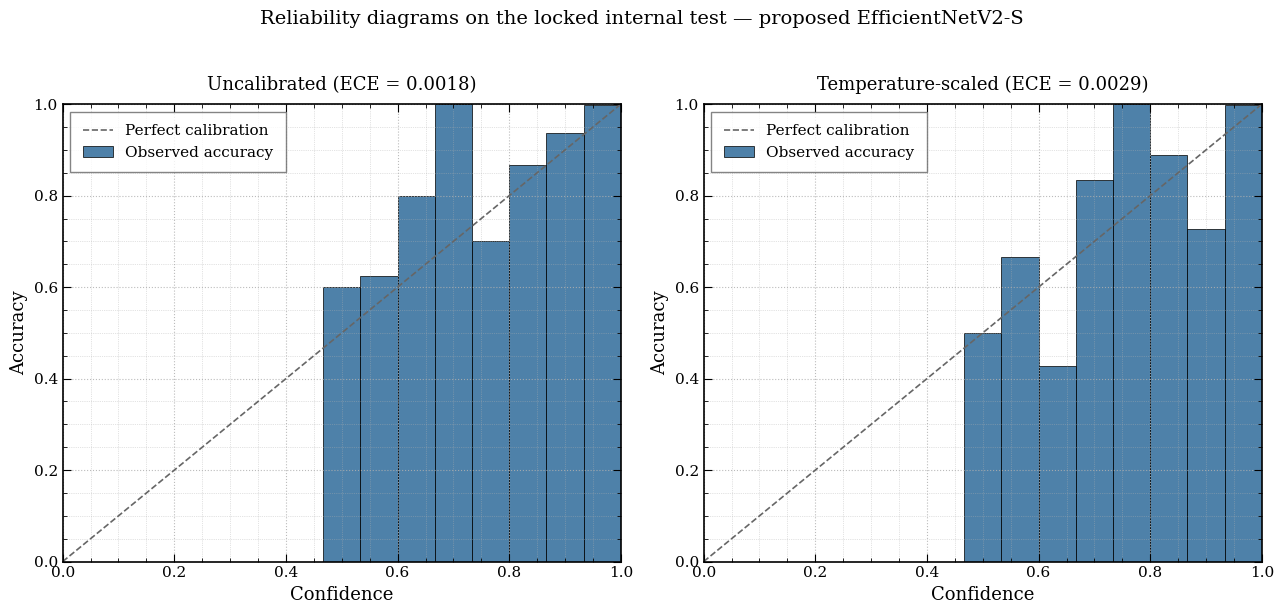

Saved: /kaggle/working/proposed_model_test_evaluation_outputs/figures/fig_01_proposed_test_reliability_diagrams.png


In [17]:
def reliability_bins(probs, targets, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == targets).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers, bin_accuracies, bin_confidences, bin_counts = [], [], [], []

    for i in range(n_bins):
        start, end = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences > start) & (confidences <= end)
        count = in_bin.sum()

        bin_centers.append((start + end) / 2)
        bin_counts.append(count)

        if count > 0:
            bin_accuracies.append(accuracies[in_bin].mean())
            bin_confidences.append(confidences[in_bin].mean())
        else:
            bin_accuracies.append(np.nan)
            bin_confidences.append(np.nan)

    return (
        np.array(bin_centers),
        np.array(bin_accuracies),
        np.array(bin_confidences),
        np.array(bin_counts)
    )


targets_np = test_targets.numpy()

centers_uncal, acc_uncal, conf_uncal, counts_uncal = reliability_bins(
    test_uncal_probs, targets_np
)
centers_cal, acc_cal, conf_cal, counts_cal = reliability_bins(
    test_cal_probs, targets_np
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, centers, accuracies, title, ece_value in [
    (axes[0], centers_uncal, acc_uncal, "Uncalibrated", test_uncal_metrics["ece"]),
    (axes[1], centers_cal, acc_cal, "Temperature-scaled", test_cal_metrics["ece"])
]:
    ax.plot([0, 1], [0, 1], linestyle="--", color="0.4", linewidth=1.2, label="Perfect calibration")

    ax.bar(
        centers, accuracies,
        width=1.0 / 15,
        color="#2F6B9A",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.85,
        label="Observed accuracy"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{title} (ECE = {ece_value:.4f})", pad=10)

    paper_axes(ax)
    ax.legend(loc="upper left", fancybox=False, borderpad=0.8)

fig.suptitle(
    "Reliability diagrams on the locked internal test — proposed EfficientNetV2-S",
    y=1.02,
    fontsize=14
)

plt.tight_layout()

figure_path = FIG_DIR / "fig_01_proposed_test_reliability_diagrams.png"
pdf_path = FIG_DIR / "fig_01_proposed_test_reliability_diagrams.pdf"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", figure_path)

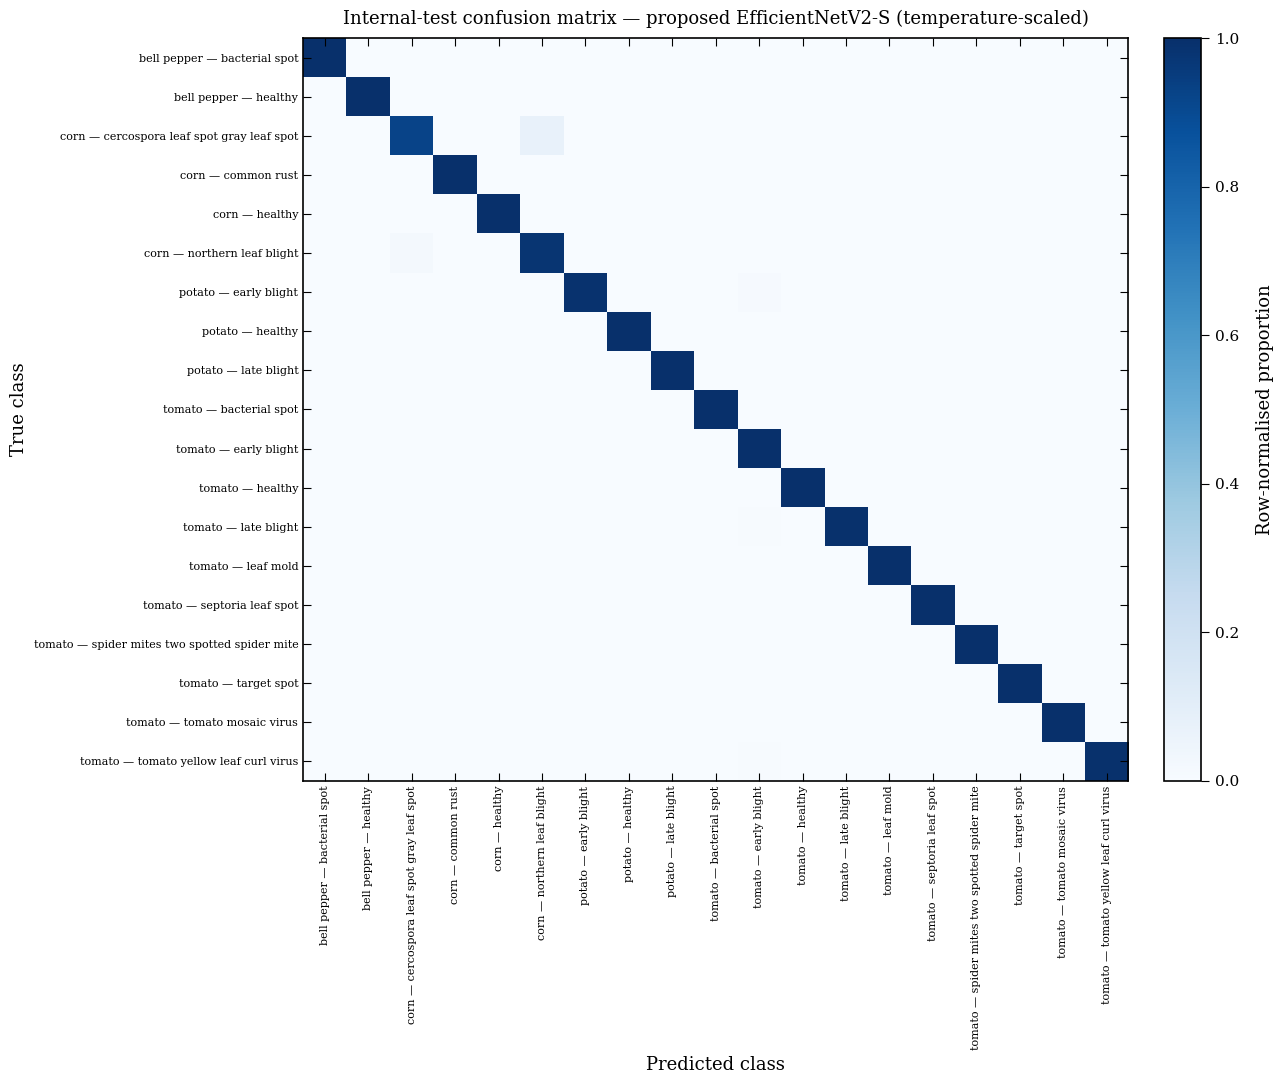

Saved: /kaggle/working/proposed_model_test_evaluation_outputs/figures/fig_02_proposed_test_confusion_matrix.png


In [18]:
readable_class_names = [
    name.replace("__", " — ").replace("_", " ")
    for name in class_names
]

confusion = confusion_matrix(
    targets_np, test_cal_preds,
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(13, 11))

image = ax.imshow(
    confusion, cmap="Blues", interpolation="nearest",
    vmin=0.0, vmax=1.0, aspect="auto"
)

colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Row-normalised proportion", rotation=90, labelpad=12)

ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(readable_class_names, rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(readable_class_names, fontsize=8)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(
    "Internal-test confusion matrix — proposed EfficientNetV2-S (temperature-scaled)",
    pad=10
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.tick_params(which="both", direction="in", top=True, right=True)

plt.tight_layout()

figure_path = FIG_DIR / "fig_02_proposed_test_confusion_matrix.png"
pdf_path = FIG_DIR / "fig_02_proposed_test_confusion_matrix.pdf"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", figure_path)

In [19]:
if baseline_available:
    baseline_metrics_df = pd.read_csv(BASELINE_METRICS_PATH)
    baseline_metrics_df.insert(0, "model", "EfficientNet-B0 (baseline)")

    comparison_df = pd.concat(
        [baseline_metrics_df, proposed_metrics_df],
        ignore_index=True
    )

    test_only = comparison_df[
        comparison_df["split"].isin(
            ["test_uncalibrated", "test_temperature_scaled"]
        )
    ].copy()

    comparison_path = TABLE_DIR / "baseline_vs_proposed_test_comparison.csv"
    comparison_df.to_csv(comparison_path, index=False)

    display(test_only[
        ["model", "split", "accuracy", "balanced_accuracy",
         "macro_f1", "nll", "brier", "ece"]
    ])

    baseline_macro_f1 = test_only.loc[
        (test_only["model"] == "EfficientNet-B0 (baseline)") &
        (test_only["split"] == "test_temperature_scaled"),
        "macro_f1"
    ].values[0]

    proposed_macro_f1 = test_only.loc[
        (test_only["model"] == "EfficientNetV2-S (proposed)") &
        (test_only["split"] == "test_temperature_scaled"),
        "macro_f1"
    ].values[0]

    macro_f1_delta = proposed_macro_f1 - baseline_macro_f1

    print(f"\nBaseline test macro-F1 (temperature-scaled): {baseline_macro_f1:.5f}")
    print(f"Proposed test macro-F1 (temperature-scaled): {proposed_macro_f1:.5f}")
    print(f"Delta (proposed - baseline): {macro_f1_delta:+.5f}")

    print("\nSaved:", comparison_path)

else:
    print(
        "Baseline metrics unavailable in this run. "
        "Attach the Notebook-04 outputs and rerun this cell for a direct comparison."
    )

,model,split,accuracy,balanced_accuracy,macro_f1,nll,brier,ece
2,EfficientNet-B0 (baseline),test_uncalibrated,0.99549,0.993468,0.993139,0.019087,0.000370,0.003408
3,EfficientNet-B0 (baseline),test_temperature_scaled,0.99549,0.993468,0.993139,0.015896,0.000337,0.002627
6,EfficientNetV2-S (proposed),test_uncalibrated,0.99549,0.993544,0.992649,0.017609,0.007734,0.001808
7,EfficientNetV2-S (proposed),test_temperature_scaled,0.99549,0.993544,0.992649,0.020060,0.007684,0.002944



Baseline test macro-F1 (temperature-scaled): 0.99314
Proposed test macro-F1 (temperature-scaled): 0.99265
Delta (proposed - baseline): -0.00049

Saved: /kaggle/working/proposed_model_test_evaluation_outputs/tables/baseline_vs_proposed_test_comparison.csv


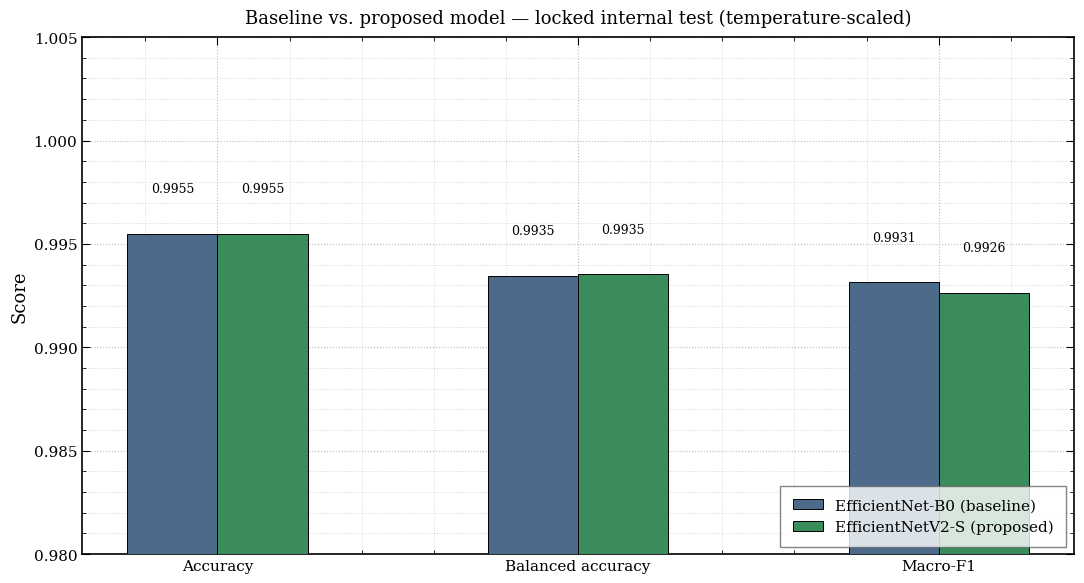

Saved: /kaggle/working/proposed_model_test_evaluation_outputs/figures/fig_03_baseline_vs_proposed_test_comparison.png


In [20]:
if baseline_available:
    plot_df = test_only[
        test_only["split"] == "test_temperature_scaled"
    ][["model", "accuracy", "balanced_accuracy", "macro_f1"]].melt(
        id_vars="model", var_name="metric", value_name="value"
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    models_order = plot_df["model"].unique()
    metrics_order = ["accuracy", "balanced_accuracy", "macro_f1"]
    bar_width = 0.25
    x_positions = np.arange(len(metrics_order))

    colors = {"EfficientNet-B0 (baseline)": "#4C6B8A", "EfficientNetV2-S (proposed)": "#3A8C5C"}

    for i, model_name in enumerate(models_order):
        subset = plot_df[plot_df["model"] == model_name].set_index("metric").loc[metrics_order]
        ax.bar(
            x_positions + i * bar_width,
            subset["value"],
            width=bar_width,
            label=model_name,
            color=colors.get(model_name, "#888888"),
            edgecolor="black",
            linewidth=0.7,
            zorder=3
        )

        for x, v in zip(x_positions + i * bar_width, subset["value"]):
            ax.text(x, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

    ax.set_xticks(x_positions + bar_width / 2)
    ax.set_xticklabels(["Accuracy", "Balanced accuracy", "Macro-F1"])
    ax.set_ylim(0.98, 1.005)
    ax.set_ylabel("Score")
    ax.set_title(
        "Baseline vs. proposed model — locked internal test (temperature-scaled)",
        pad=10
    )

    paper_axes(ax)
    ax.legend(loc="lower right", fancybox=False, borderpad=0.8)

    plt.tight_layout()

    figure_path = FIG_DIR / "fig_03_baseline_vs_proposed_test_comparison.png"
    pdf_path = FIG_DIR / "fig_03_baseline_vs_proposed_test_comparison.pdf"

    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", figure_path)

In [21]:
run_metadata = {
    "notebook": "06_proposed_model_temperature_scaling_and_internal_test_evaluation",
    "completed_utc": datetime.now(timezone.utc).isoformat(),
    "model": "EfficientNetV2-S",
    "checkpoint_path": str(PROPOSED_CHECKPOINT_PATH),
    "fitted_temperature": fitted_temperature,
    "calibration_uncalibrated": calib_uncal_metrics,
    "calibration_temperature_scaled": calib_cal_metrics,
    "test_uncalibrated": test_uncal_metrics,
    "test_temperature_scaled": test_cal_metrics,
    "confirmed_near_duplicate_exclusions": data_protocol.get(
        "confirmed_near_duplicate_exclusions", "not_recorded"
    ),
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__
}

run_metadata_path = METADATA_DIR / "proposed_model_test_run_metadata.json"

with open(run_metadata_path, "w") as file:
    json.dump(run_metadata, file, indent=2)

print(json.dumps(run_metadata, indent=2))

assert metrics_path.exists()
assert uncal_report_path.exists()
assert cal_report_path.exists()
assert predictions_path.exists()
assert run_metadata_path.exists()

print("\n" + "=" * 78)
print("NOTEBOOK 06 COMPLETED")
print("=" * 78)
print("\nProposed EfficientNetV2-S — internal test (temperature-scaled)")
print("Accuracy:", round(test_cal_metrics["accuracy"], 5))
print("Balanced accuracy:", round(test_cal_metrics["balanced_accuracy"], 5))
print("Macro-F1:", round(test_cal_metrics["macro_f1"], 5))
print("ECE:", round(test_cal_metrics["ece"], 5))
print("\nOutput directory:", OUTPUT_DIR)
print(
    "\nReminder: this internal-test result must not be used to re-select "
    "architecture, hyperparameters, or thresholds. Any further tuning "
    "requires a fresh split or a separate held-out set."
)

{
  "notebook": "06_proposed_model_temperature_scaling_and_internal_test_evaluation",
  "completed_utc": "2026-08-22T05:31:06.664959+00:00",
  "model": "EfficientNetV2-S",
  "checkpoint_path": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb05/nd5/best_efficientnetv2s_main19.pt",
  "fitted_temperature": 0.6160976886749268,
  "calibration_uncalibrated": {
    "split": "calibration_uncalibrated",
    "accuracy": 0.9981232405380044,
    "balanced_accuracy": 0.9978407776613508,
    "macro_f1": 0.9978920241071627,
    "nll": 0.010250160156810722,
    "brier": 0.0042290987093371295,
    "ece": 0.004561619047153588
  },
  "calibration_temperature_scaled": {
    "split": "calibration_temperature_scaled",
    "accuracy": 0.9981232405380044,
    "balanced_accuracy": 0.9978407776613508,
    "macro_f1": 0.9978920241071627,
    "nll": 0.007218902085310896,
    "brier": 0.0037405178507783836,
    "ece": 0.0016194764882428649
  },
  "test_uncalibrated": {
    "split": "test_uncalibrate